In [1]:
import os
import csv
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

cwd = os.getcwd()
root = os.path.dirname(cwd) if cwd.endswith('/code') else cwd
FIG_DIR = root + '/paper/figures'
os.makedirs(FIG_DIR, exist_ok=True)

with open(root + '/artifacts/results_grid.csv', newline='', encoding='utf-8') as f:
    rows = list(csv.DictReader(f))

buckets = defaultdict(lambda: {'lv': [], 'mu': [], 'L': None, 'E': None})
for r in rows:
    key = (r['model_id'], int(r['train_tokens_real']))
    buckets[key]['lv'].append(float(r['val_loss']))
    buckets[key]['mu'].append(float(r['mu_landscape']))
    buckets[key]['L'] = int(r['n_layer'])
    buckets[key]['E'] = int(r['n_embd'])
agg = []
for (mid, tok), d in sorted(buckets.items()):
    agg.append(
        {
            'model_id': mid,
            'tokens': tok,
            'lv': float(np.mean(d['lv'])),
            'mu': float(np.mean(d['mu'])),
            'L': d['L'],
            'E': d['E'],
        }
    )

lv = np.array([p['lv'] for p in agg])
logt = np.log(np.maximum(np.array([p['tokens'] for p in agg], dtype=float), 1.0))
mu = np.array([p['mu'] for p in agg])
X = np.column_stack([np.ones(len(agg)), lv, logt])
beta, _, _, _ = np.linalg.lstsq(X, mu, rcond=None)
resid = mu - X @ beta
ss_res = float(np.sum(resid**2))
ss_tot = float(np.sum((mu - np.mean(mu)) ** 2))
r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float('nan')
print(f'Grid CSV: {len(rows)} rows, {len(set(r["model_id"] for r in rows))} model_id')
print(f'Pooled OLS on grid (mean over seeds): R^2={r2:.4f}, beta={beta}')

by_ms = defaultdict(list)
for r in rows:
    by_ms[(r['model_id'], int(r['seed']))].append(
        (int(r['train_tokens_real']), float(r['val_loss']), float(r['mu_landscape']))
    )
neg_dl_pairs = 0
neg_dl_pos_dmu = 0
for pts in by_ms.values():
    pts = sorted(pts, key=lambda x: x[0])
    for i in range(len(pts) - 1):
        dlv = pts[i + 1][1] - pts[i][1]
        dmu = pts[i + 1][2] - pts[i][2]
        if dlv < 0:
            neg_dl_pairs += 1
            if dmu > 0:
                neg_dl_pos_dmu += 1
frac = neg_dl_pos_dmu / neg_dl_pairs if neg_dl_pairs else float('nan')

Grid CSV: 5760 rows, 36 model_id
Pooled OLS on grid (mean over seeds): R^2=0.2667, beta=[ 0.55852725 -0.03534106 -0.01387934]


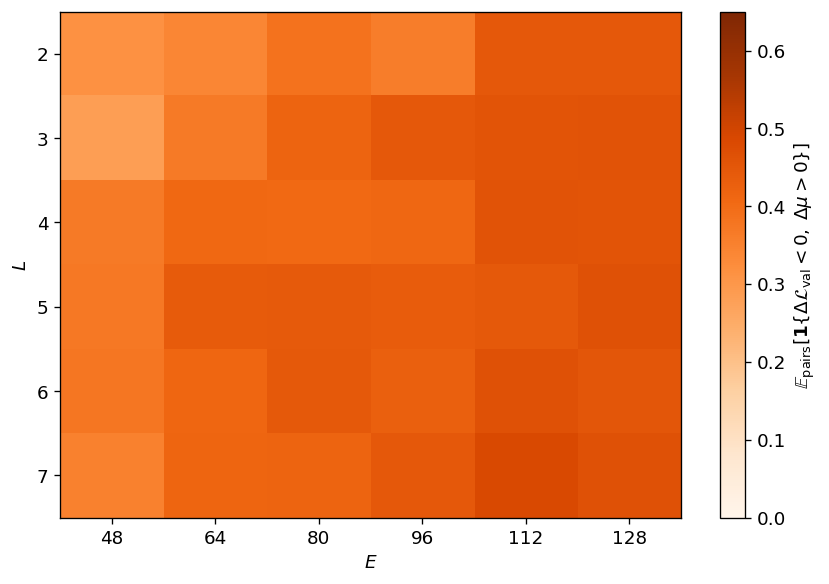

In [2]:
RNG = np.random.default_rng(42)
N_BOOT = 800

rows_by_ms = defaultdict(list)
for r in rows:
    rows_by_ms[(r['model_id'], int(r['seed']))].append(r)
for lst in rows_by_ms.values():
    lst.sort(key=lambda x: int(x['checkpoint_idx']))

tot_pairs = pos_pairs = 0
for lst in rows_by_ms.values():
    lv = [float(x['val_loss']) for x in lst]
    mu = [float(x['mu_landscape']) for x in lst]
    for i in range(len(lst) - 1):
        if lv[i + 1] - lv[i] < 0:
            tot_pairs += 1
            if mu[i + 1] - mu[i] > 0:
                pos_pairs += 1
frac_global = pos_pairs / tot_pairs if tot_pairs else float('nan')

layers = sorted({int(r['n_layer']) for r in rows})
embds = sorted({int(r['n_embd']) for r in rows})
le_frac = {}
for L in layers:
    for E in embds:
        sub = [r for r in rows if int(r['n_layer']) == L and int(r['n_embd']) == E]
        by_ms = defaultdict(list)
        for r in sub:
            by_ms[(r['model_id'], int(r['seed']))].append(r)
        for lst in by_ms.values():
            lst.sort(key=lambda x: int(x['checkpoint_idx']))
        tp = pp = 0
        for lst in by_ms.values():
            lv = [float(x['val_loss']) for x in lst]
            mu = [float(x['mu_landscape']) for x in lst]
            for i in range(len(lst) - 1):
                if lv[i + 1] - lv[i] < 0:
                    tp += 1
                    if mu[i + 1] - mu[i] > 0:
                        pp += 1
        le_frac[L, E] = pp / tp if tp else float('nan')

traj_fracs = []
for lst in rows_by_ms.values():
    lv = [float(x['val_loss']) for x in lst]
    mu = [float(x['mu_landscape']) for x in lst]
    neg = pos = 0
    for i in range(len(lst) - 1):
        if lv[i + 1] - lv[i] < 0:
            neg += 1
            if mu[i + 1] - mu[i] > 0:
                pos += 1
    if neg > 0:
        traj_fracs.append(pos / neg)
arr = np.array(traj_fracs, dtype=float)
n_t = len(arr)
boots = []
for _ in range(N_BOOT):
    idx = RNG.integers(0, n_t, size=n_t)
    boots.append(float(np.mean(arr[idx])))
boots.sort()
ci_lo = boots[int(0.025 * N_BOOT)] if boots else float('nan')
ci_hi = boots[int(0.975 * N_BOOT)] if boots else float('nan')

depths = layers
widths = embds
mat = np.full((len(depths), len(widths)), np.nan)
d_i = {d: i for i, d in enumerate(depths)}
w_i = {w: i for i, w in enumerate(widths)}
for (L, E), f in le_frac.items():
    mat[d_i[L], w_i[E]] = f

fig, ax = plt.subplots(figsize=(7.2, 5))
vmax = 0.65
im = ax.imshow(np.clip(mat, 0, vmax), aspect='auto', cmap='Oranges', vmin=0, vmax=vmax)
ax.set_xticks(np.arange(len(widths)), labels=[str(w) for w in widths])
ax.set_yticks(np.arange(len(depths)), labels=[str(d) for d in depths])
ax.set_xlabel(r'$E$')
ax.set_ylabel(r'$L$')
plt.colorbar(im, ax=ax, label=r'$\mathbb{E}_{\mathrm{pairs}}[\mathbf{1}\{\Delta\mathcal{L}_{\mathrm{val}}<0,\;\Delta\mu>0\}]$')
fig.tight_layout()
out_nm = root + '/paper/figures/fig_grid_nonmonotonicity_heatmap.png'
fig.savefig(out_nm, dpi=200, bbox_inches='tight')
plt.show()



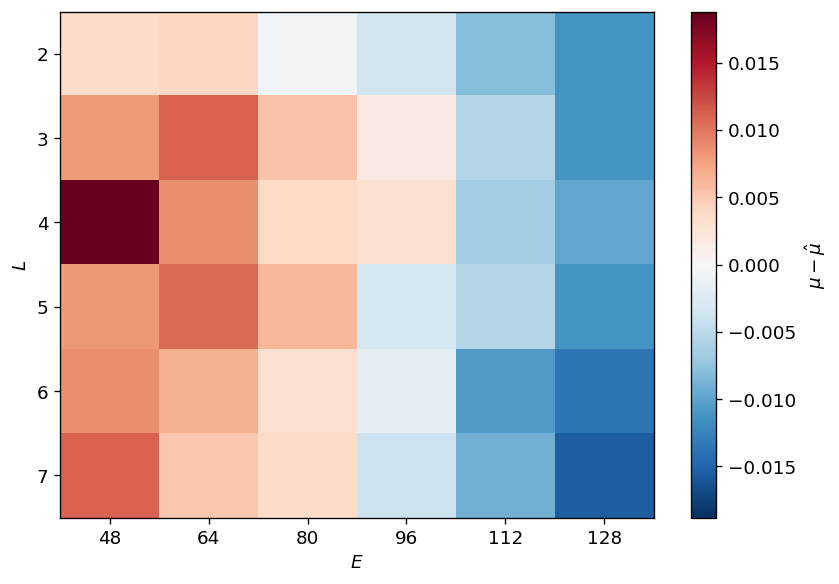

In [3]:
depths = sorted({p['L'] for p in agg})
widths = sorted({p['E'] for p in agg})
d_idx = {d: i for i, d in enumerate(depths)}
w_idx = {w: i for i, w in enumerate(widths)}
acc = defaultdict(float)
cnt = defaultdict(int)
for p, r in zip(agg, resid):
    key = (p['L'], p['E'])
    acc[key] += float(r)
    cnt[key] += 1
mat = np.full((len(depths), len(widths)), np.nan)
for (L, E), s in acc.items():
    mat[d_idx[L], w_idx[E]] = s / cnt[(L, E)]

fig, ax = plt.subplots(figsize=(7.2, 5))
vmax = np.nanmax(np.abs(mat))
im = ax.imshow(mat, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_xticks(np.arange(len(widths)), labels=[str(w) for w in widths])
ax.set_yticks(np.arange(len(depths)), labels=[str(d) for d in depths])
ax.set_xlabel(r'$E$')
ax.set_ylabel(r'$L$')
plt.colorbar(im, ax=ax, label=r'$\mu - \hat{\mu}$')
fig.tight_layout()
out_path = root + '/paper/figures/fig_grid_mu_residual_heatmap.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()
